In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
import pickle
import gc
import warnings
warnings.filterwarnings('ignore')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f"GPU: {gpus[0]}")

plt.rcParams['figure.dpi']       = 150
plt.rcParams['axes.facecolor']   = '#0d0d0d'
plt.rcParams['figure.facecolor'] = '#0d0d0d'
plt.rcParams['axes.edgecolor']   = '#444444'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['text.color']       = 'white'
plt.rcParams['grid.color']       = '#222222'
plt.rcParams['grid.linestyle']   = '--'
plt.rcParams['grid.alpha']       = 0.4

I0000 00:00:1779589815.946088    6798 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779589816.378646    6798 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779589819.845584    6798 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [2]:
core_path    = os.getcwd()
orbital_df = pd.read_pickle(os.path.join(core_path, 'data/lvl3/orbital_df.pkl'))

# Option A — family members only
family_df = orbital_df[orbital_df['is_family_member']].copy().reset_index(drop=True)

print(f"Family members   : {len(family_df):,}")
print(f"Unique families  : {family_df['family_1'].nunique()}")
print(f"\nFamily size stats:")
print(family_df.groupby('family_1').size().describe())

Family members   : 230,607
Unique families  : 98

Family size stats:
count       98.000000
mean      2353.132653
std       5239.487654
min          3.000000
25%        114.750000
50%        407.500000
75%       1900.250000
max      34323.000000
dtype: float64


In [3]:
FEATURES_A = ['a_p', 'e_p', 'sin_i_p', 'g', 's']
FEATURES_B = ['a_p', 'e_p', 'sin_i_p', 'g', 's',
              'rms_a', 'rms_e', 'rms_sin_i', 'LCE']

# Label encode
le = LabelEncoder()
y  = le.fit_transform(family_df['family_1'].values)
n_classes = len(le.classes_)

print(f"Family members : {len(family_df):,}")
print(f"Classes        : {n_classes}")

# Class weights
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(n_classes),
    y=y
)
class_weight_dict = dict(enumerate(class_weights_arr))
print(f"Min class weight : {class_weights_arr.min():.3f}")
print(f"Max class weight : {class_weights_arr.max():.3f}")

dl_results = {}

Family members : 230,607
Classes        : 98
Min class weight : 0.069
Max class weight : 784.378


In [4]:
def build_multiclass_model(input_dim, n_classes,
                           layers_config=[512, 256, 128, 64],
                           dropout_rate=0.3,
                           learning_rate=1e-3):
    inputs = keras.Input(shape=(input_dim,))
    x      = inputs

    for units in layers_config:
        x = layers.Dense(units, activation='relu',
                         kernel_initializer='he_normal',
                         kernel_regularizer=keras.regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy',
                 keras.metrics.SparseTopKCategoricalAccuracy(k=3, name='top3_acc')]
    )
    return model

In [6]:
EPOCHS     = 400
BATCH_SIZE = 2048

for feat_name, features in [
    ('Set_A_orbital', FEATURES_A),
    ('Set_B_full',    FEATURES_B),
]:
    print(f"\n{'='*55}")
    print(f"Feature {feat_name}")
    print(f"{'='*55}")

    X = family_df[features].values

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
    )

    # Scale
    scaler  = RobustScaler()
    X_train = scaler.fit_transform(X_train)
    X_val   = scaler.transform(X_val)
    X_test  = scaler.transform(X_test)

    print(f"Train : {len(X_train):,} | Val : {len(X_val):,} | Test : {len(X_test):,}")

    # Build
    model = build_multiclass_model(
        input_dim=len(features),
        n_classes=n_classes,
        layers_config=[512, 256, 128, 64],
        dropout_rate=0.3,
        learning_rate=1e-3
    )
    model.summary()

    # Callbacks
    cb_list = [
        callbacks.EarlyStopping(
            monitor='val_accuracy', patience=10,
            restore_best_weights=True, mode='max'
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_accuracy', factor=0.5,
            patience=4, min_lr=1e-6, mode='max', verbose=1
        ),
        callbacks.ModelCheckpoint(
            filepath=os.path.join('data', 'results', 'classification_results', f'07a_ii_best_{feat_name}.keras'),
            monitor='val_accuracy', save_best_only=True,
            mode='max', verbose=0
        )
    ]

    # Train
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weight_dict,
        callbacks=cb_list,
        verbose=1
    )

    # Evaluate
    y_pred_proba = model.predict(X_test, batch_size=BATCH_SIZE)
    y_pred       = np.argmax(y_pred_proba, axis=1)

    acc         = accuracy_score(y_test, y_pred)
    f1_macro    = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    per_class_f1 = f1_score(y_test, y_pred, average=None)

    print(f"\n=== DL Dense Multiclass — {feat_name} ===")
    print(f"Accuracy        : {acc:.4f}")
    print(f"F1 Macro        : {f1_macro:.4f}")
    print(f"F1 Weighted     : {f1_weighted:.4f}")
    print(f"Min per-class F1: {per_class_f1.min():.4f} "
          f"(family {le.classes_[per_class_f1.argmin()]})")

    dl_results[feat_name] = {
        'history':      history.history,
        'scaler':       scaler,
        'y_test':       y_test,
        'y_pred':       y_pred,
        'y_pred_proba': y_pred_proba,
        'acc':          acc,
        'f1_macro':     f1_macro,
        'f1_weighted':  f1_weighted,
        'per_class_f1': per_class_f1,
        'features':     features
    }

    del model
    keras.backend.clear_session()
    gc.collect()


Feature Set_A_orbital
Train : 166,036 | Val : 18,449 | Test : 46,122


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 98)             │         6,370 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,762 (725.63 KB)

 Trainable params: 183,842 (718.13 KB)

...

Epoch 1/400


I0000 00:00:1779590252.017788    7331 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_130866__.53


73/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0480 - loss: 4.7274 - top3_acc: 0.1152

I0000 00:00:1779590259.303546    7333 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_130866__.53


82/82 ━━━━━━━━━━━━━━━━━━━━ 17s 106ms/step - accuracy: 0.1005 - loss: 4.5727 - top3_acc: 0.2265 - val_accuracy: 0.2923 - val_loss: 3.6063 - val_top3_acc: 0.6343 - learning_rate: 0.0010
Epoch 2/400
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2607 - loss: 3.3867 - top3_acc: 0.5349 - val_accuracy: 0.4991 - val_loss: 2.5604 - val_top3_acc: 0.7780 - learning_rate: 0.0010
Epoch 3/400
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3489 - loss: 2.7745 - top3_acc: 0.6684 - val_accuracy: 0.5892 - val_loss: 1.9486 - val_top3_acc: 0.8443 - learning_rate: 0.0010
Epoch 4/400
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4066 - loss: 2.3315 - top3_acc: 0.7454 - val_accuracy: 0.6198 - val_loss: 1.6538 - val_top3_acc: 0.8930 - learning_rate: 0.0010
Epoch 5/400
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4527 - loss: 2.1010 - top3_acc: 0.7942 - val_accuracy: 0.6606 - val_loss: 1.4511 - val_top3_acc: 0.9148 - learning_rate: 0.0010
Epoch 6/400
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 6m

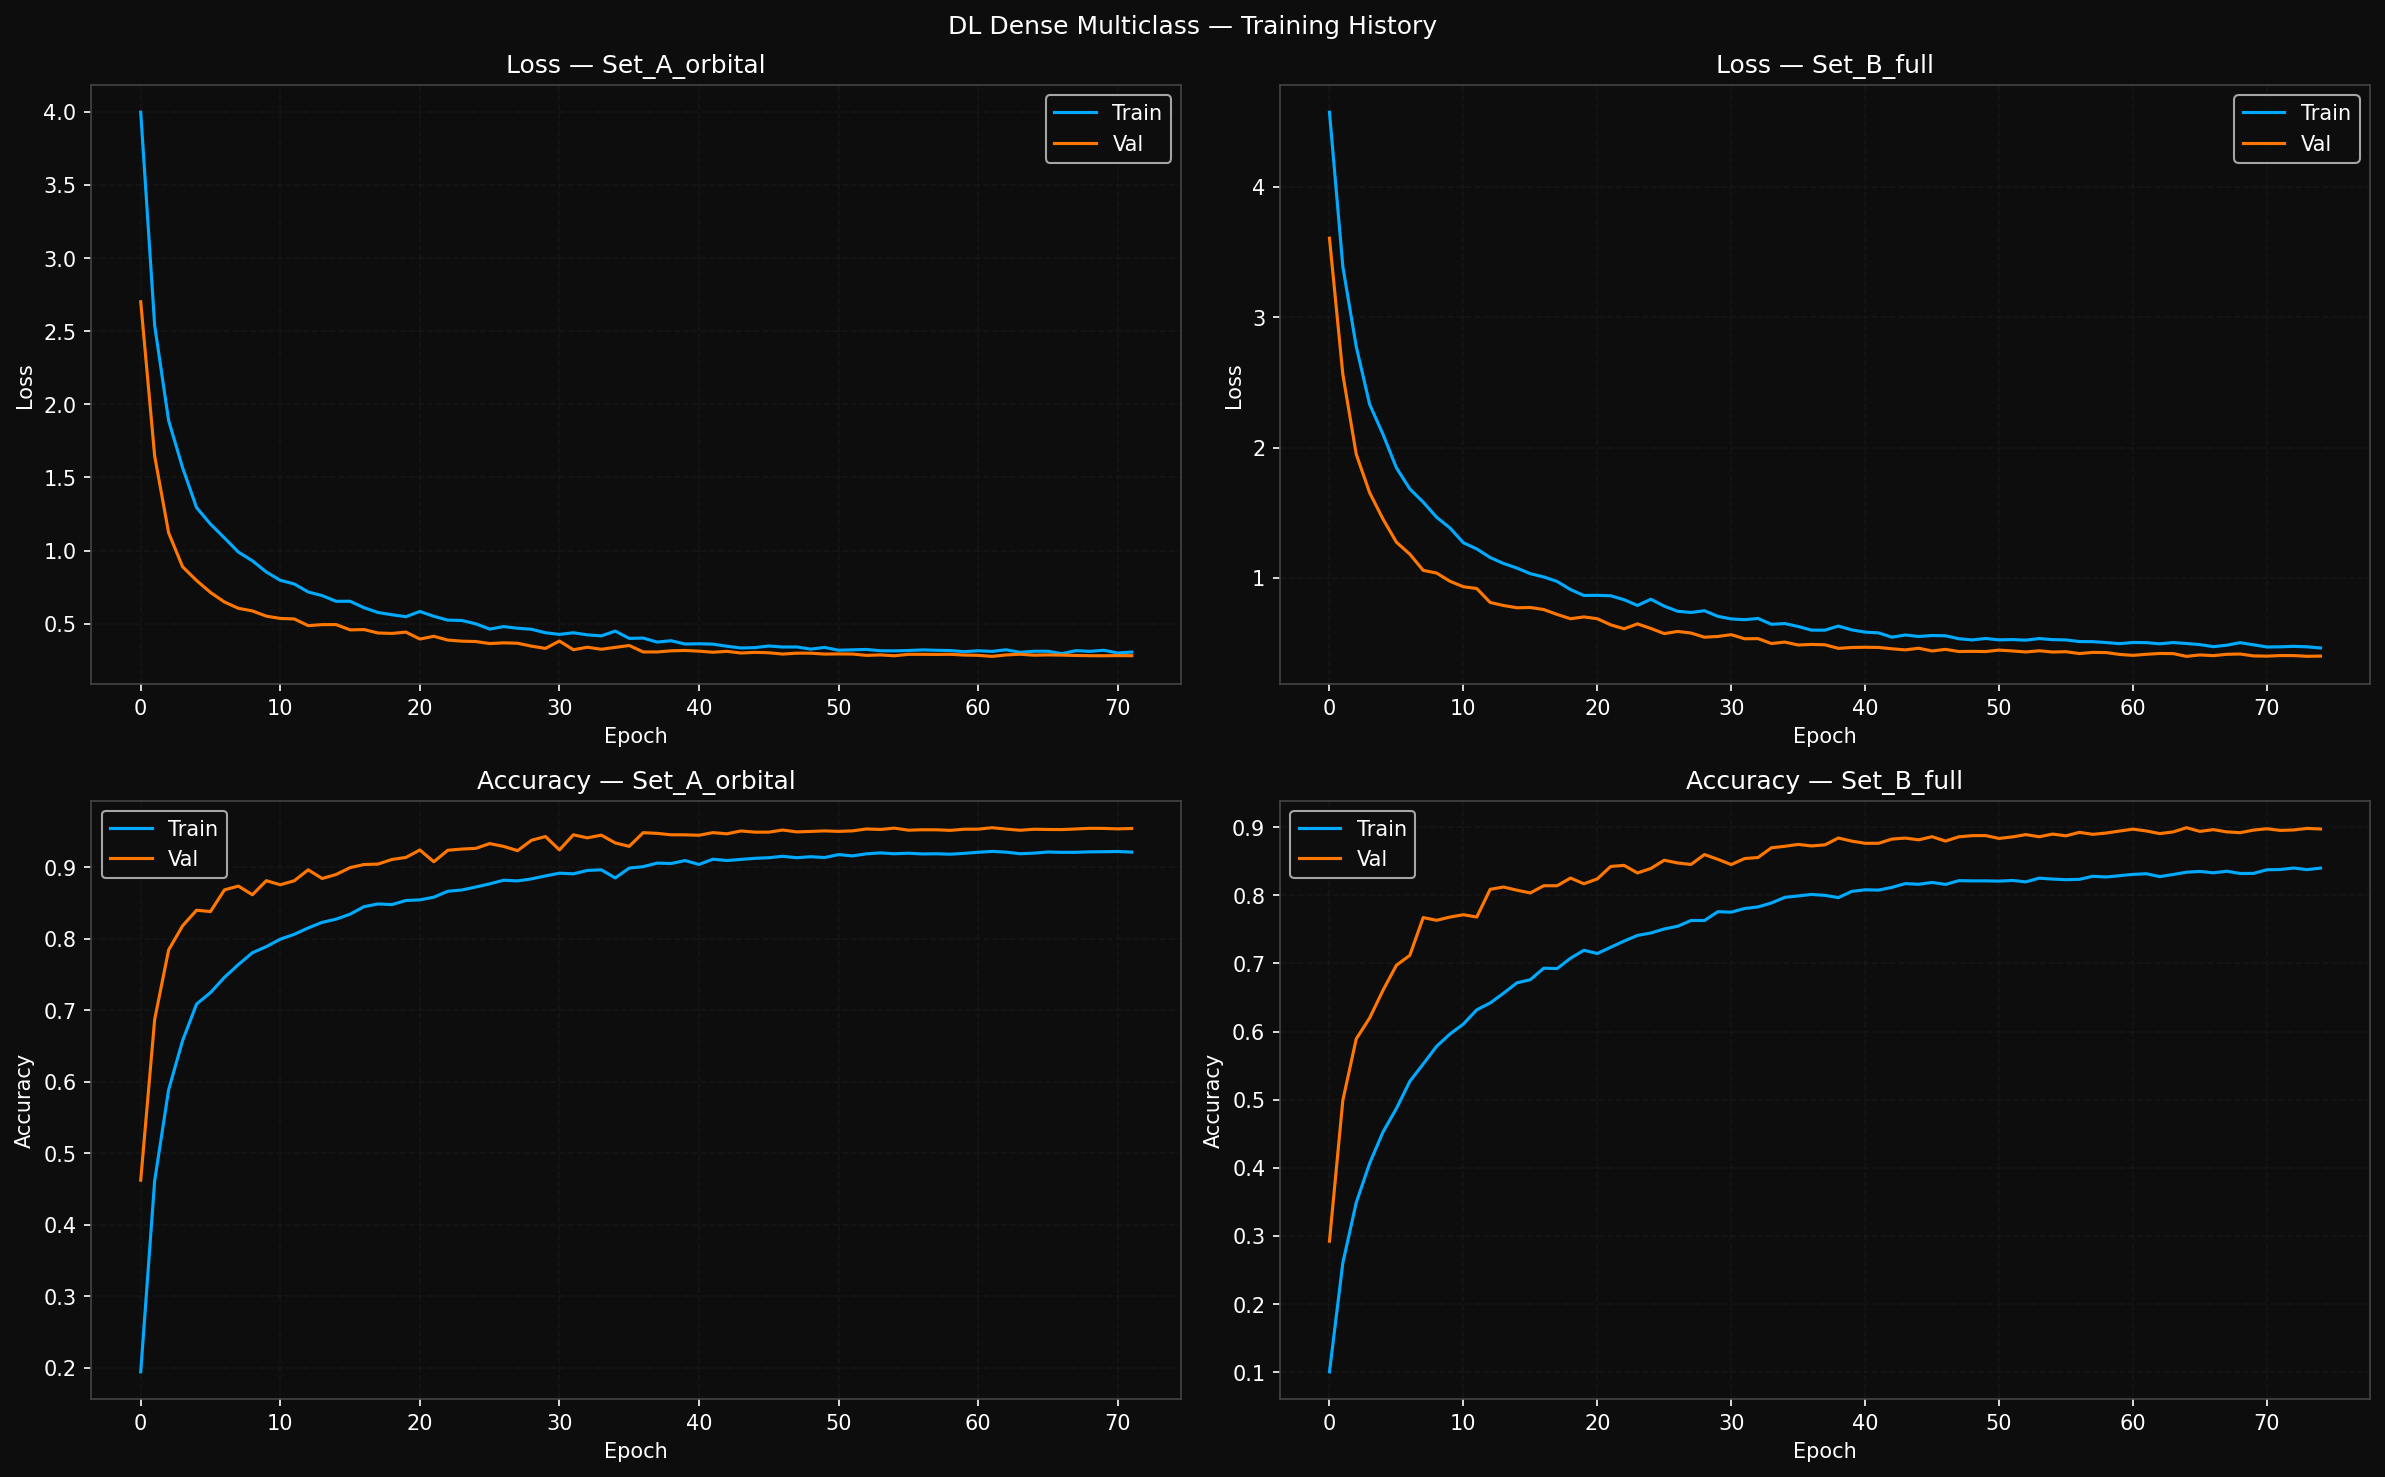

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col, feat_name in enumerate(['Set_A_orbital', 'Set_B_full']):
    hist = dl_results[feat_name]['history']

    # Loss
    axes[0, col].plot(hist['loss'],     label='Train', color='#00aaff')
    axes[0, col].plot(hist['val_loss'], label='Val',   color='#ff7700')
    axes[0, col].set_title(f'Loss — {feat_name}')
    axes[0, col].set_xlabel('Epoch')
    axes[0, col].set_ylabel('Loss')
    axes[0, col].legend()
    axes[0, col].grid(True)

    # Accuracy
    axes[1, col].plot(hist['accuracy'],     label='Train', color='#00aaff')
    axes[1, col].plot(hist['val_accuracy'], label='Val',   color='#ff7700')
    axes[1, col].set_title(f'Accuracy — {feat_name}')
    axes[1, col].set_xlabel('Epoch')
    axes[1, col].set_ylabel('Accuracy')
    axes[1, col].legend()
    axes[1, col].grid(True)

plt.suptitle('DL Dense Multiclass — Training History', fontsize=12)
plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '05b_ii_dl_history.png'), dpi=200, bbox_inches='tight')
plt.show()

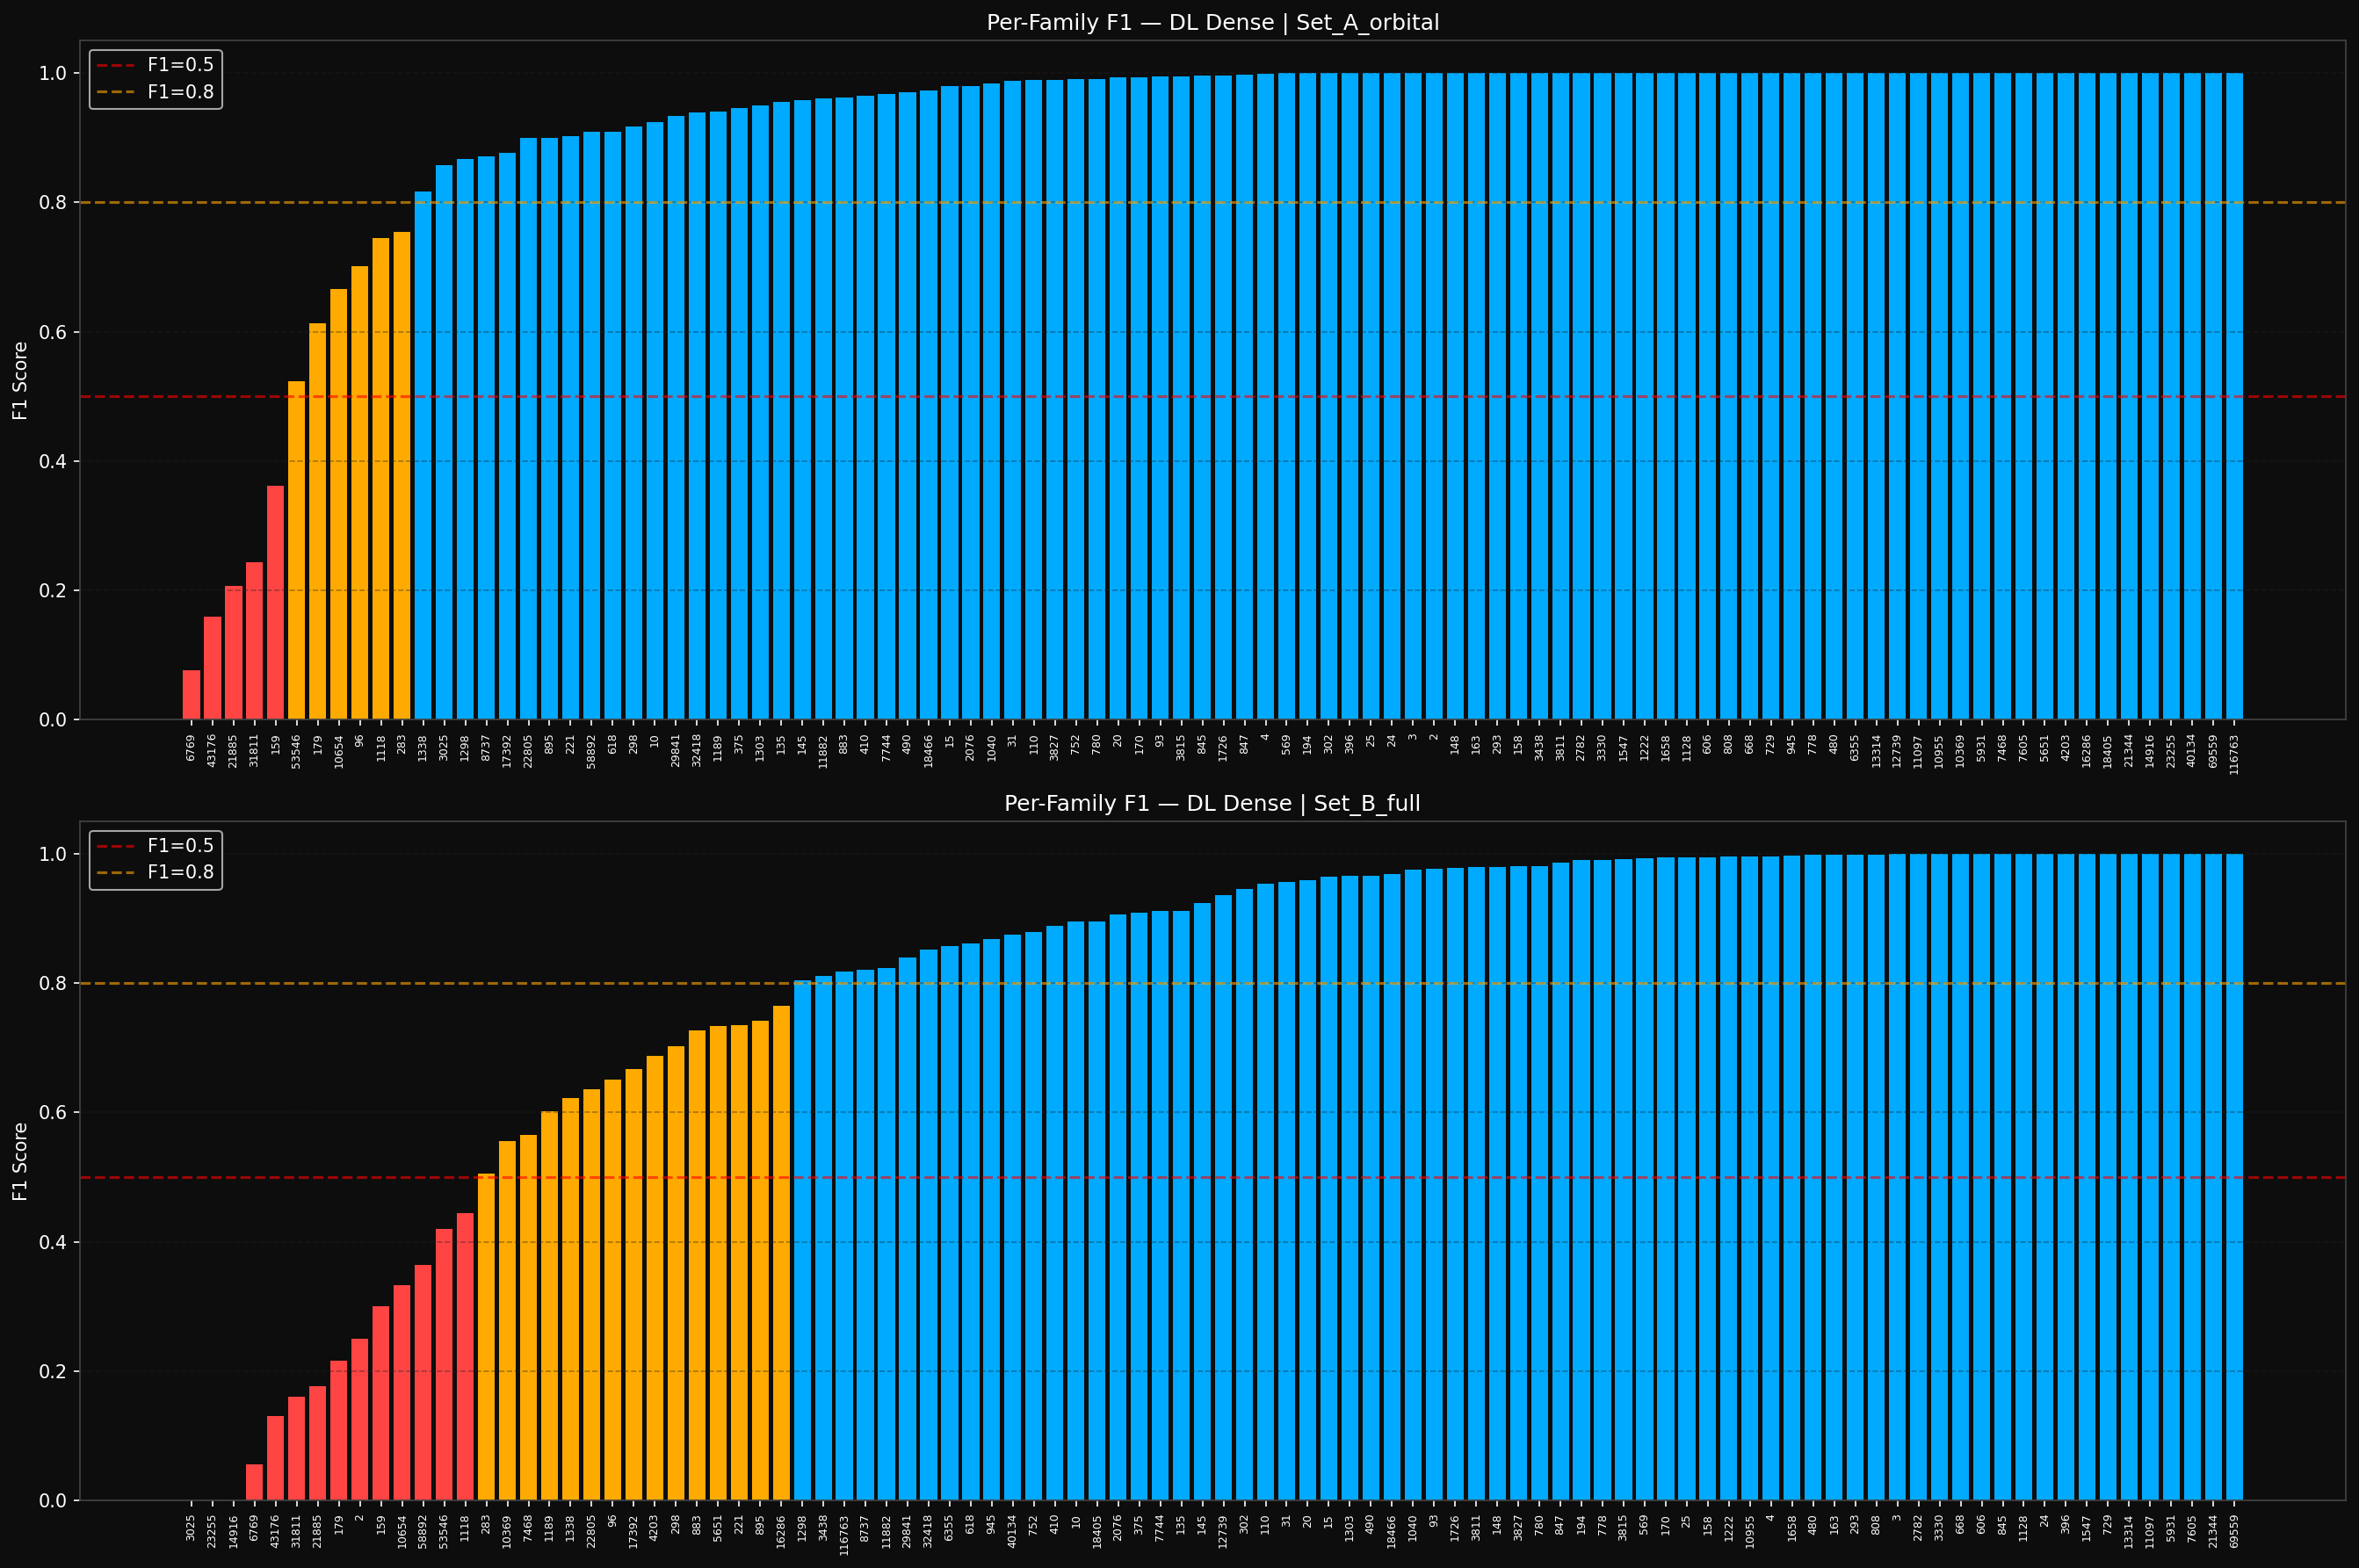

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(18, 12))

for ax, feat_name in zip(axes, ['Set_A_orbital', 'Set_B_full']):
    per_f1      = dl_results[feat_name]['per_class_f1']
    sorted_idx  = np.argsort(per_f1)
    family_names = [str(le.classes_[i]) for i in sorted_idx]

    colors = ['#ff4444' if f < 0.5 else '#ffaa00' if f < 0.8 else '#00aaff'
              for f in per_f1[sorted_idx]]

    ax.bar(range(len(per_f1)), per_f1[sorted_idx],
           color=colors, edgecolor='none')
    ax.axhline(0.5, color='red',    linestyle='--', alpha=0.6, label='F1=0.5')
    ax.axhline(0.8, color='orange', linestyle='--', alpha=0.6, label='F1=0.8')
    ax.set_xticks(range(len(per_f1)))
    ax.set_xticklabels(family_names, rotation=90, fontsize=6)
    ax.set_ylabel('F1 Score')
    ax.set_title(f'Per-Family F1 — DL Dense | {feat_name}')
    ax.legend()
    ax.grid(True, axis='y')

plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '05b_ii_dl_perclass_f1.png'), dpi=200, bbox_inches='tight')
plt.show()

In [11]:
with open(os.path.join('data', 'results', 'classification_results', '07a_i_multiclass_rf_results.pkl'), 'rb') as f:
    rf_results = pickle.load(f)

print(f"\n{'='*70}")
print(f"{'Multiclass — RF vs DL Dense':^70}")
print(f"{'='*70}")
print(f"{'Model':<30} {'Acc':>8} {'F1 Macro':>10} {'F1 Weighted':>12}")
print(f"{'-'*70}")

for feat_name, res in rf_results.items():
    print(f"{'RF_'+feat_name:<30} {res['acc']:>8.4f} "
          f"{res['f1_macro']:>10.4f} {res['f1_weighted']:>12.4f}")

for feat_name, res in dl_results.items():
    print(f"{'DL_'+feat_name:<30} {res['acc']:>8.4f} "
          f"{res['f1_macro']:>10.4f} {res['f1_weighted']:>12.4f}")


                     Multiclass — RF vs DL Dense                      
Model                               Acc   F1 Macro  F1 Weighted
----------------------------------------------------------------------
RF_Set_A_orbital                 0.9992     0.9919       0.9992
RF_Set_B_full                    0.9992     0.9941       0.9992
DL_Set_A_orbital                 0.9564     0.9183       0.9675
DL_Set_B_full                    0.9010     0.8010       0.9227


In [12]:
save_dict = {
    feat_name: {k: v for k, v in res.items() if k != 'scaler'}
    for feat_name, res in dl_results.items()
}

with open(os.path.join('data', 'results', 'classification_results', '07a_ii_dl_multiclass_results.pkl'), 'wb') as f:
    pickle.dump(save_dict, f)

print("Saved → data/results/07a_ii_dl_multiclass_results.pkl")

Saved → data/results/07a_ii_dl_multiclass_results.pkl
